In [38]:
import glob 
import os
import numpy as np

from data_utils import parse_p2s, load_s_e_l_segs, segment_lengths, generate_more_segments, split_eat_noneat

from tqdm import tqdm

### Loading Test data

In [2]:
test_dir="/media/ns/Seagate/oct18"

In [3]:
def find_all_labelled_files(root_dir):
    files=glob.glob(root_dir+"/*")
    for file in files:
        if "toupload" in file:
            files.remove(file)
    # print(files)

    segments_files=[]

    file=files[0]
    for file in files:
        segments_all=glob.glob(file+"/**/segments.txt",recursive=True) 
        for segment in segments_all:
            if "cam1" in segment and not "pill" in segment:
                segments_files.append(segment)

    len(segments_files)

     
    dir_segs={}
    for filename in segments_files:
        try:
            dir_segs[filename]=load_s_e_l_segs(filename)
        except Exception as e:
            print("Error in loading file", filename)
            print(e)
            print('-------------------')
    return dir_segs

In [4]:
dir_segs=find_all_labelled_files(test_dir)
print(f"Total segments.txt files found: {len(dir_segs)}")

Total segments.txt files found: 9


In [5]:
seg_files=list(dir_segs.keys())
seg_files

['/media/ns/Seagate/oct18/skylar/cam1/rosbag2_skylar_18_1/rosbag2_skylar_18_1/segments.txt',
 '/media/ns/Seagate/oct18/skylar/cam1/rosbag2_skylar_18/rosbag2_skylar_18/segments.txt',
 '/media/ns/Seagate/oct18/ashleigh/cam1/rosbag2_ashleigh_18/rosbag2_ashleigh_18/segments.txt',
 '/media/ns/Seagate/oct18/ashleigh/cam1/rosbag2_ashleigh_18_1/rosbag2_ashleigh_18_1/segments.txt',
 '/media/ns/Seagate/oct18/ashley/cam1/rosbag2_ashley/rosbag2_ashley/segments.txt',
 '/media/ns/Seagate/oct18/ashley/cam1/rosbag2_ashley_1/rosbag2_ashley_1/segments.txt',
 '/media/ns/Seagate/oct18/lauren/cam1/rosbag2_lauren/rosbag2_lauren/segments.txt',
 '/media/ns/Seagate/oct18/lauren/cam1/rosbag2_lauren_1/rosbag2_lauren_1/segments.txt',
 '/media/ns/Seagate/oct18/lauren/cam1/rosbag2_lauren_2/rosbag2_lauren_2/segments.txt']

In [6]:
eating_file2segs, not_eating_file2segs=split_eat_noneat(dir_segs)
print(f"Total eating segments: {sum([len(v) for v in eating_file2segs.values()])}")
print(f"Total not eating segments: {sum([len(v) for v in not_eating_file2segs.values()])}")

Total eating segments: 48
Total not eating segments: 65


In [7]:
de=segment_lengths(eating_file2segs)
dne=segment_lengths(not_eating_file2segs)

print(f"Total eating segments: {len(de)}")
print(f"Total not eating segments: {len(dne)}")

print(f"min eating segment: {min(de)}")
print(f"max eating segment: {max(de)}") 
print(f"min not eating segment: {min(dne)}")
print(f"max not eating segment: {max(dne)}")
print(f"median eating segment: {np.median(de)}")
print(f"median not eating segment: {np.median(dne)}")

Total eating segments: 48
Total not eating segments: 65
min eating segment: 30
max eating segment: 447
min not eating segment: 31
max not eating segment: 709
median eating segment: 109.0
median not eating segment: 58.0


In [8]:
seq_length=30

eating_segs=generate_more_segments(eating_file2segs, seq_length=seq_length, max_overlap=10)
not_eating_segs=generate_more_segments(not_eating_file2segs, seq_length=seq_length, max_overlap=10)

print('Fixed length segments: ', seq_length)
print(f"Total eating segments: {sum([len(v) for v in eating_segs.values()])}")
print(f"Total not eating segments: {sum([len(v) for v in not_eating_segs.values()])}")

Fixed length segments:  30
Total eating segments: 252
Total not eating segments: 211


In [9]:
#create dataset
all_rows_eating=[]
for filepath in eating_segs.keys():
    dirname=os.path.dirname(filepath)
    ses=parse_p2s(dirname)
    fixed_segs=eating_segs[filepath]
    rows=np.array([ses[s:e] for s,e in fixed_segs] )
    all_rows_eating.append(rows)

all_rows_eating=np.concatenate(all_rows_eating, axis=0)

all_rows_not_eating=[]
for filepath in not_eating_segs.keys():
    dirname=os.path.dirname(filepath)
    ses=parse_p2s(dirname)
    fixed_segs=not_eating_segs[filepath]
    rows=np.array([ses[s:e] for s,e in fixed_segs] )
    all_rows_not_eating.append(rows)
all_rows_not_eating=np.concatenate(all_rows_not_eating, axis=0)

all_rows_eating.shape, all_rows_not_eating.shape

((252, 30, 50), (211, 30, 50))

In [10]:
X_test=np.concatenate([all_rows_eating, all_rows_not_eating], axis=0)
y_test=np.concatenate([np.ones(all_rows_eating.shape[0]), np.zeros(all_rows_not_eating.shape[0])], axis=0)
X_test.shape, y_test.shape

((463, 30, 50), (463,))

### Loading training data

In [11]:
filepath_oct25="/media/ns/Seagate/oct25"
filepath_nov6="/media/ns/Seagate/nov6"
filepath_nov8="/media/ns/Seagate/nov8"
filepath_nov15="/media/ns/Seagate/nov15"

In [12]:

files_oct25=glob.glob(filepath_oct25+"/*")
for file in files_oct25:
    if 'toupload' in file:
        del files_oct25[files_oct25.index(file)]
files_oct25

['/media/ns/Seagate/oct25/madison',
 '/media/ns/Seagate/oct25/amy',
 '/media/ns/Seagate/oct25/cassidy']

In [13]:
files_nov6=glob.glob(filepath_nov6+"/*")
for file in files_nov6:
    #if it is a file
    if os.path.isfile(file):
        del files_nov6[files_nov6.index(file)]
    if 'toupload' in file:
        del files_nov6[files_nov6.index(file)] 
for file in files_nov6: 
    if 'need' in file: 
        del files_nov6[files_nov6.index(file)]
for file in files_nov6: 
    if 'labelled' in file: 
        del files_nov6[files_nov6.index(file)]
files_nov6

['/media/ns/Seagate/nov6/joey',
 '/media/ns/Seagate/nov6/lucy',
 '/media/ns/Seagate/nov6/patrick',
 '/media/ns/Seagate/nov6/katie',
 '/media/ns/Seagate/nov6/katy',
 '/media/ns/Seagate/nov6/corinna',
 '/media/ns/Seagate/nov6/jessie',
 '/media/ns/Seagate/nov6/ashley',
 '/media/ns/Seagate/nov6/makalyah',
 '/media/ns/Seagate/nov6/ana']

In [14]:
len(files_nov6)

10

In [15]:
#remove issues.
issues=['katy', 'katie', 'ana', 'ashley']
for issue in issues:
    for file in files_nov6:
        if issue in file:
            del files_nov6[files_nov6.index(file)]
            
files_nov6

['/media/ns/Seagate/nov6/joey',
 '/media/ns/Seagate/nov6/lucy',
 '/media/ns/Seagate/nov6/patrick',
 '/media/ns/Seagate/nov6/corinna',
 '/media/ns/Seagate/nov6/jessie',
 '/media/ns/Seagate/nov6/makalyah']

In [16]:

files_nov8=glob.glob(filepath_nov8+"/*")
for file in files_nov8:
    if 'toupload' in file:
        del files_nov8[files_nov8.index(file)]
files_nov8

['/media/ns/Seagate/nov8/anna', '/media/ns/Seagate/nov8/jack']

In [17]:
files_nov15=glob.glob(filepath_nov15+"/*")
for file in files_nov15:
    if 'toupload' in file:
        del files_nov15[files_nov15.index(file)]
for file in files_nov15: 
    if 'need' in file: 
        del files_nov15[files_nov15.index(file)]
files_nov15

['/media/ns/Seagate/nov15/sheikh',
 '/media/ns/Seagate/nov15/hafizul',
 '/media/ns/Seagate/nov15/rabiul']

In [18]:
all_files=files_oct25+files_nov6+files_nov8+files_nov15
len(all_files)

14

In [19]:
dir=all_files[0]
dir_segs=find_all_labelled_files(dir)
print(f"Total segments.txt files found: {len(dir_segs)}")

Total segments.txt files found: 2


In [20]:
dir_segs_all={}
for dir in all_files:
    dir_segs=find_all_labelled_files(dir)
    print('dir=', dir)
    print(f"Total segments.txt files found: {len(dir_segs)}\n") 
    for k,v in dir_segs.items():
        dir_segs_all[k]=v

len(dir_segs_all)

dir= /media/ns/Seagate/oct25/madison
Total segments.txt files found: 2

dir= /media/ns/Seagate/oct25/amy
Total segments.txt files found: 0

dir= /media/ns/Seagate/oct25/cassidy
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/joey
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/lucy
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/patrick
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/corinna
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/jessie
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/makalyah
Total segments.txt files found: 3

dir= /media/ns/Seagate/nov8/anna
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov8/jack
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov15/sheikh
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov15/hafizul
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov15/rabiul
Total segments.txt files found: 2



27

In [21]:
eating_file2segs, not_eating_file2segs=split_eat_noneat(dir_segs_all)
print(f"Total eating segments: {sum([len(v) for v in eating_file2segs.values()])}")
print(f"Total not eating segments: {sum([len(v) for v in not_eating_file2segs.values()])}")

Total eating segments: 86
Total not eating segments: 106


In [22]:
de=segment_lengths(eating_file2segs)
dne=segment_lengths(not_eating_file2segs)

print(f"Total eating segments: {len(de)}")
print(f"Total not eating segments: {len(dne)}")

print(f"min eating segment: {min(de)}")
print(f"max eating segment: {max(de)}") 
print(f"min not eating segment: {min(dne)}")
print(f"max not eating segment: {max(dne)}")
print(f"median eating segment: {np.median(de)}")
print(f"median not eating segment: {np.median(dne)}")

Total eating segments: 86
Total not eating segments: 106
min eating segment: 30
max eating segment: 677
min not eating segment: 30
max not eating segment: 503
median eating segment: 123.0
median not eating segment: 76.5


In [23]:
seq_length=30

eating_segs=generate_more_segments(eating_file2segs, seq_length=seq_length, max_overlap=10)
not_eating_segs=generate_more_segments(not_eating_file2segs, seq_length=seq_length, max_overlap=10)

print('Fixed length segments: ', seq_length)
print(f"Total eating segments: {sum([len(v) for v in eating_segs.values()])}")
print(f"Total not eating segments: {sum([len(v) for v in not_eating_segs.values()])}")

Fixed length segments:  30
Total eating segments: 699
Total not eating segments: 477


In [24]:
#create dataset
all_rows_eating=[]
for filepath in eating_segs.keys():
    dirname=os.path.dirname(filepath)
    ses=parse_p2s(dirname)
    fixed_segs=eating_segs[filepath]
    rows=np.array([ses[s:e] for s,e in fixed_segs] )
    all_rows_eating.append(rows)

all_rows_eating=np.concatenate(all_rows_eating, axis=0)

all_rows_not_eating=[]
for filepath in not_eating_segs.keys():
    dirname=os.path.dirname(filepath)
    ses=parse_p2s(dirname)
    fixed_segs=not_eating_segs[filepath]
    rows=np.array([ses[s:e] for s,e in fixed_segs] )
    all_rows_not_eating.append(rows)
all_rows_not_eating=np.concatenate(all_rows_not_eating, axis=0)

all_rows_eating.shape, all_rows_not_eating.shape

((699, 30, 50), (477, 30, 50))

In [25]:
X_train=np.concatenate([all_rows_eating, all_rows_not_eating], axis=0)
y_train=np.concatenate([np.ones(all_rows_eating.shape[0]), np.zeros(all_rows_not_eating.shape[0])], axis=0)
X_train.shape, y_train.shape

((1176, 30, 50), (1176,))

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import glob 
import torch
import torch.nn as nn
import torch.optim as optim 
import time 
from torch.utils.data import DataLoader, TensorDataset

In [31]:
train_loader =  DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)),
    batch_size=32, shuffle=True)

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)),
    batch_size=32, shuffle=True)

In [32]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device 

device(type='cuda')

In [33]:
class LSTM(nn.Module):
    
    def __init__(self,input_dim,hidden_dim,output_dim,layer_num, seq_len):
        super(LSTM,self).__init__()
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lstm = torch.nn.LSTM(input_dim,hidden_dim,layer_num,batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim,output_dim)
        self.bn = nn.BatchNorm1d(seq_len)
        
    def forward(self,inputs):
        x = self.bn(inputs)
        lstm_out,(hn,cn) = self.lstm(x)
        out = self.fc(lstm_out[:,-1,:])
        return out

In [34]:
n_hidden = 128
n_joints = 25*2
n_categories = 2
n_layer = 3
seq_len = 30
rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

LSTM(
  (lstm): LSTM(50, 128, num_layers=3, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (bn): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [35]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-4 
optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)

In [39]:
n_iters = 1_000
print_every = 100

In [40]:
all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
    
    current_loss = 0
    for j, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        rnn.zero_grad()
        output = rnn(data)
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()
        current_loss += loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 


  0%|          | 0/1000 [00:00<?, ?it/s]

 10%|█         | 100/1000 [00:27<03:59,  3.75it/s]

1100 2.4218417543452233


 20%|██        | 200/1000 [00:53<03:37,  3.68it/s]

1200 0.4539636799017899


...

1800 0.05917995149502531


 90%|█████████ | 900/1000 [04:04<00:27,  3.61it/s]

1900 0.1947011040756479


100%|██████████| 1000/1000 [04:30<00:00,  3.69it/s]

2000 0.003429321073781466


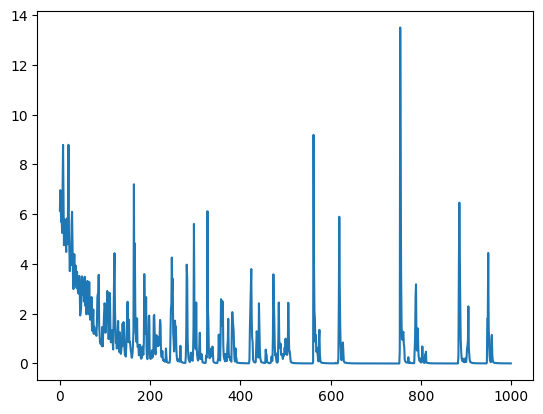

In [41]:
plt.plot(all_losses)

In [42]:
X_test_tensor=torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor=torch.tensor(y_test, dtype=torch.float32).to(device)

rnn.eval()
with torch.no_grad():
    y_pred=rnn(X_test_tensor)
    loss=criterion(y_pred, y_test_tensor.long())
    print('loss=', loss.item())
    y_pred=y_pred.argmax(dim=1)
    acc=(y_pred==y_test_tensor).float().mean()
    print('acc=', acc.item())

loss= 3.3046483993530273
acc= 0.5723541975021362
